# **1. Imputación de Datos Faltantes**

**Objetivo:** Rellenar los valores faltantes de las 13 variables continuas para poder entrenar la Red Bayesiana Gaussiana sin descartar registros.

---

Arie González

In [1]:
# --- Manejo de datos ---
import pandas as pd
import numpy as np
from pathlib import Path

# --- Imputación ---
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# --- Visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## **0. Carga de los Datos**

Se parte del CSV con las 13 variables continuas ya limpias que se generó en el notebook anterior (`1_analisis_eda.ipynb`). Adicionalmente se recupera la columna `classification` del dataset original, ya que se usará como variable auxiliar durante la imputación.

In [2]:
# Continuas ya limpias por el EDA
df = pd.read_csv('/Users/arieglez/Desktop/MétodosRazonamiento/MRI-art_2-RBG/notebook/data/processed/ckd_precessed.csv')

# Se recupera 'classification' del dataset original
raw = pd.read_csv('/Users/arieglez/Desktop/MétodosRazonamiento/MRI-art_2-RBG/data/raw/ckd.csv')
df['classification'] = raw['classification'].str.strip().str.lower()

df.head()

,age,bp,sg,al,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,classification
0,48.0,80.0,1.020,1.0,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,ckd
1,7.0,50.0,1.020,4.0,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,ckd
2,62.0,80.0,1.010,2.0,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,ckd
3,48.0,70.0,1.005,4.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,ckd
4,51.0,80.0,1.010,2.0,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,ckd


## **1. Patrón de Faltantes**

En el EDA se observó que **el porcentaje de faltantes es mucho mayor en pacientes con `ckd` que en pacientes sanos** (por ejemplo `rbc`: 57% vs 6%, `rc`: 50% vs 5%). Esto es un indicio de que los datos **no faltan completamente al azar**, por lo que la estrategia de imputación debe considerarlo.

In [3]:
continuas = ['age', 'bp', 'sg', 'al', 'bgr', 'bu', 'sc',
             'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']

# Faltantes por variable, desglosados por diagnóstico
faltantes = pd.DataFrame({
    'pct_total'   : (df[continuas].isna().mean() * 100).round(1),
    'pct_ckd'     : (df[df['classification'] == 'ckd'][continuas].isna().mean() * 100).round(1),
    'pct_notckd'  : (df[df['classification'] == 'notckd'][continuas].isna().mean() * 100).round(1),
}).sort_values('pct_total', ascending=False)

faltantes

,pct_total,pct_ckd,pct_notckd
rc,32.8,49.6,4.7
wc,26.5,39.6,4.7
pot,22.0,33.2,3.3
sod,21.8,32.8,3.3
pcv,17.8,26.8,2.7
hemo,13.0,18.4,4.0
sg,11.8,16.8,3.3
al,11.5,16.4,3.3
bgr,11.0,15.2,4.0
bu,4.8,5.2,4.0


**Observaciones:**

- El porcentaje de faltantes por variable es consistentemente mayor en el grupo `ckd` que en el grupo `notckd`. Variables como `rbc`, `rc` y `wc` presentan hasta 10 veces más faltantes entre pacientes enfermos.

- Esto confirma que los datos **no faltan al azar**: la ausencia está asociada al diagnóstico.

- Eliminar las filas con faltantes reduciría el dataset principalmente en el grupo enfermo, generando un sesgo. Por eso se opta por imputar en lugar de descartar.

## **2. Elección del Método de Imputación**

Se consideraron tres alternativas:

| Método | Ventaja | Desventaja |
|---|---|---|
| **Media / mediana** | Simple, no requiere ajuste. | Ignora la relación entre variables y reduce la varianza. |
| **KNN** | Considera la similitud entre pacientes. | Muy sensible a la escala de las variables. |
| **MICE (IterativeImputer)** | Estima cada variable como una regresión de las demás, de forma iterativa. | Requiere más cómputo. |

Se elige **MICE** porque su lógica coincide con la de la Red Bayesiana Gaussiana que se construirá después: cada variable se modela como una combinación lineal de las demás bajo un supuesto gaussiano. Adicionalmente, como los faltantes dependen del diagnóstico, se incluye `classification` codificada como 0/1 durante la imputación y se descarta al final (la GBN solo admite variables continuas).

In [4]:
# Se codifica classification como binaria para pasarla al imputador
df['clase_bin'] = (df['classification'] == 'ckd').astype(int)

# Variables que entran al imputador
cols_imputar = continuas + ['clase_bin']

imputer = IterativeImputer(random_state=42, max_iter=15)

df_imp = pd.DataFrame(
    imputer.fit_transform(df[cols_imputar]),
    columns=cols_imputar,
    index=df.index
)

# Se descarta la variable auxiliar
df_imp = df_imp.drop(columns='clase_bin')

df_imp.head()

,age,bp,sg,al,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
0,48.0,80.0,1.020,1.0,121.000000,36.0,1.2,139.942414,4.197281,15.4,44.0,7800.0,5.200000
1,7.0,50.0,1.020,4.0,110.320278,18.0,0.8,131.685802,3.402636,11.3,38.0,6000.0,4.619463
2,62.0,80.0,1.010,2.0,423.000000,53.0,1.8,131.968897,4.831249,9.6,31.0,7500.0,3.805148
3,48.0,70.0,1.005,4.0,117.000000,56.0,3.8,111.000000,2.500000,11.2,32.0,6700.0,3.900000
4,51.0,80.0,1.010,2.0,106.000000,26.0,1.4,136.046536,3.760707,11.6,35.0,7300.0,4.600000


**Observaciones:**

- Los valores originales del dataset conservan su forma (por ejemplo `age = 48.0`, `bp = 80.0`).

- Los valores estimados por el imputador se distinguen porque aparecen con múltiples decimales (por ejemplo `bgr ≈ 110.32` en la fila 1, donde antes había un `NaN`).

- Los valores imputados se mantienen dentro del rango clínico esperado para cada variable.

## **3. Validación de la Imputación**

Se comparan las estadísticas por grupo antes y después de imputar para verificar que las diferencias clínicas entre `ckd` y `notckd` se mantengan.

In [5]:
# Comparación de medias por grupo, antes y después de imputar
comparacion = pd.DataFrame({
    'antes_ckd'     : df[df['classification'] == 'ckd'][continuas].mean(),
    'despues_ckd'   : df_imp[df['classification'] == 'ckd'].mean(),
    'antes_notckd'  : df[df['classification'] == 'notckd'][continuas].mean(),
    'despues_notckd': df_imp[df['classification'] == 'notckd'].mean(),
})

comparacion.round(2)

,antes_ckd,despues_ckd,antes_notckd,despues_notckd
age,54.54,54.48,46.52,46.53
bp,79.62,79.46,71.35,71.36
sg,1.01,1.01,1.02,1.02
al,1.72,1.76,0.00,0.00
bgr,175.42,172.37,107.72,108.59
bu,72.39,72.08,32.80,32.82
sc,4.41,4.34,0.87,0.92
sod,133.90,134.63,141.73,141.71
pot,4.88,4.68,4.34,4.33
hemo,10.65,10.82,15.19,15.17


**Observaciones:**

- Las medias por grupo antes y después de imputar son prácticamente iguales: la imputación no desplazó el centro de las distribuciones.

- Las diferencias clínicas entre `ckd` y `notckd` que se documentaron en el EDA se conservan: la hemoglobina, el volumen celular y el conteo de eritrocitos siguen siendo notablemente más bajos en los pacientes enfermos, mientras que la creatinina, la urea y la glucosa siguen siendo más altas.

- Se concluye que el método MICE con `classification` como variable auxiliar preserva la señal clínica del dataset original y es válido para alimentar la Red Bayesiana Gaussiana.

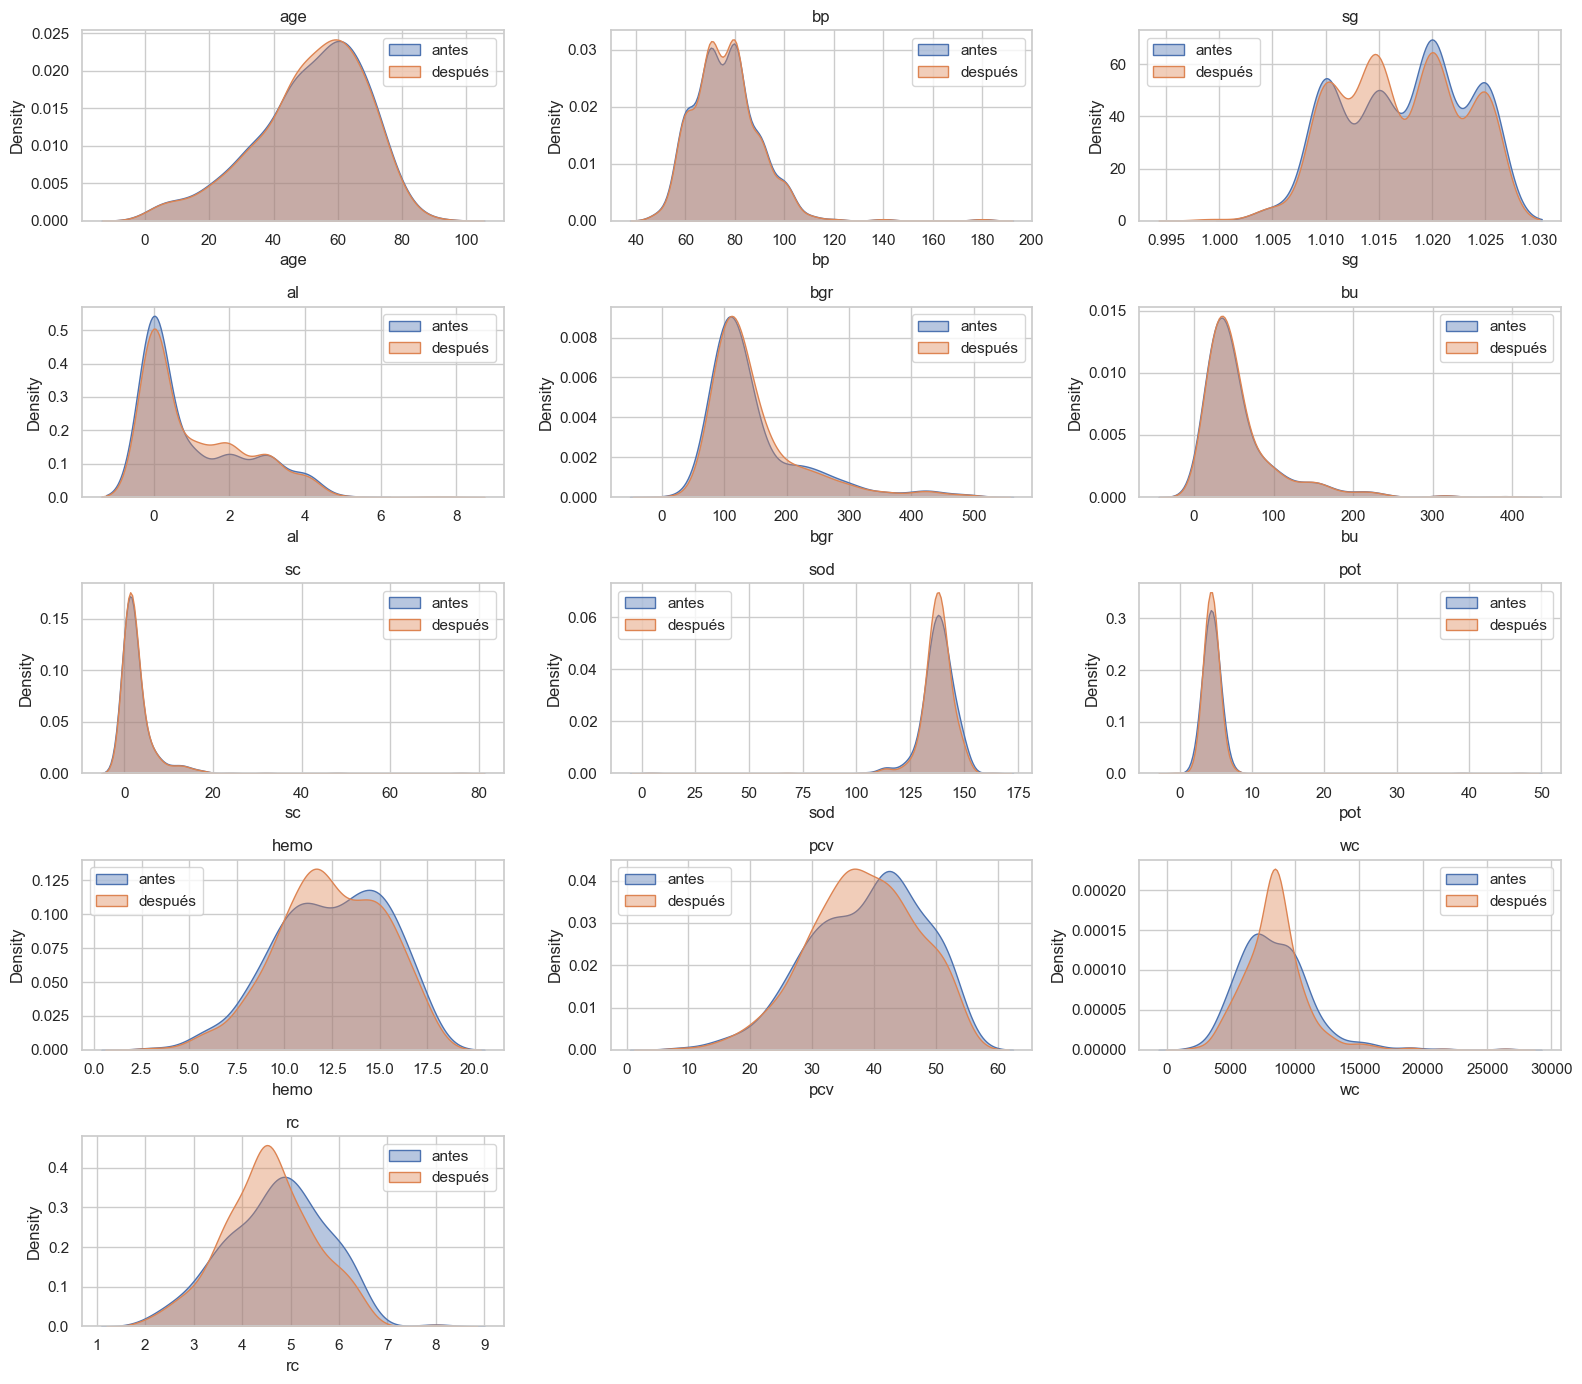

In [6]:
# Distribución de cada variable antes vs después de imputar
fig, axes = plt.subplots(5, 3, figsize=(16, 14))
axes = axes.ravel()

for i, v in enumerate(continuas):
    sns.kdeplot(df[v].dropna(), ax=axes[i], label='antes', fill=True, alpha=0.4)
    sns.kdeplot(df_imp[v], ax=axes[i], label='después', fill=True, alpha=0.4)
    axes[i].set_title(v)
    axes[i].legend()

# Se apagan los recuadros sobrantes
for j in range(len(continuas), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Observaciones:**

- Las medias por grupo se conservan tras la imputación: las diferencias entre enfermos y sanos que se documentaron en el EDA (hemoglobina baja en `ckd`, creatinina alta en `ckd`, etc.) siguen presentes.

- Las densidades antes/después mantienen la misma forma general, sin desplazamientos evidentes.

- No quedan valores faltantes en ninguna variable continua.

In [7]:
# Verificación final
print(f'Filas:    {df_imp.shape[0]}')
print(f'Columnas: {df_imp.shape[1]}')
print(f'Nulos restantes: {df_imp.isna().sum().sum()}')

Filas:    400
Columnas: 13
Nulos restantes: 0


## **4. Exportar Base Imputada**

In [9]:
# Guardar en 'data/processed' para el siguiente notebook
file_path = Path('data/processed/ckd_imputado.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

df_imp.to_csv(file_path, index=False)